# The one step improvement Figure

Compare gradient statistics across different INR samplers (`random`, `NMT`, `2d_grid_linear`, `2d_grid_adaptive`, original) evaluated on the same set of checkpoints from a single training run.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

## 1. Setup & Imports

In [3]:
from __future__ import annotations

import sys
import re
from pathlib import Path

# Add repo root to sys.path so local modules resolve correctly
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import copy
import random

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from torch_geometric.data import Data

# Local utilities from this repo
from gradient_test import (
    compute_sampled_gradients,
    _load_checkpoint,
    _build_graph,
    _apply_sampler_overrides,
    _weighted_mse,
    _call_sampler,
    _set_all_seeds,
    _flatten_gradients,
)
from train_utility_sampling.SamplerWrapper import create_inr_sampler
from utils.load_inr import create_inr_instance

print("Imports OK — repo root:", REPO_ROOT)

Imports OK — repo root: /pscratch/sd/g/gzhao27/INR/INR_SAMPLE


## 2. Define Checkpoint Path & Device

In [4]:
data_path= "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/checkpoints/2026-05-02-21-55-20NS1024_sgd_lrtune_random_re_10000_sampling_2e-3_lr_1e-5_depth_3_t100"
data_path="/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/checkpoints/2026-05-03-05-13-25NS1024_sgd_lrtune_random_re_10000_sampling_2e-3_lr_1e-5_depth_6_t100"
CHECKPOINT_DIR = Path(
    data_path
)

assert CHECKPOINT_DIR.is_dir(), f"Checkpoint dir not found: {CHECKPOINT_DIR}"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

# Collect all numeric step checkpoints and sort them
NUMERIC_RE = re.compile(r"^(\d+)\.pt$")
checkpoint_steps = sorted(
    [(int(m.group(1)), p) for p in CHECKPOINT_DIR.glob("*.pt") if (m := NUMERIC_RE.match(p.name))],
    key=lambda x: x[0],
)
step_list = [s for s, _ in checkpoint_steps]
path_list = [p for _, p in checkpoint_steps]

print(f"\nFound {len(checkpoint_steps)} checkpoints: steps {step_list[:5]} ... {step_list[-3:]}")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

Found 99 checkpoints: steps [0, 100, 200, 300, 400] ... [9800, 9900, 9999]


In [5]:
# CHECKPOINT_DIR = Path(
#     "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/checkpoints/"
#     "2026-04-18-20-53-04NS1024_single_random_re_10000_sampling_2e-3_lr_1e-4_depth_6_t100"
# )

# assert CHECKPOINT_DIR.is_dir(), f"Checkpoint dir not found: {CHECKPOINT_DIR}"

# DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# print(f"Device : {DEVICE}")
# print(f"GPU    : {torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'N/A'}")

# # Collect all numeric step checkpoints and sort them
# NUMERIC_RE = re.compile(r"^(\d+)\.pt$")
# checkpoint_steps = sorted(
#     [(int(m.group(1)), p) for p in CHECKPOINT_DIR.glob("*.pt") if (m := NUMERIC_RE.match(p.name))],
#     key=lambda x: x[0],
# )
# step_list = [s for s, _ in checkpoint_steps]
# path_list = [p for _, p in checkpoint_steps]

# print(f"\nFound {len(checkpoint_steps)} checkpoints: steps {step_list[:5]} ... {step_list[-3:]}")

## 3. Define Sampler Configurations

Each entry maps a human-readable sampler name to a `sampler_overrides` dict passed to `compute_sampled_gradients()`.
`None` overrides preserves the original checkpoint sampler.

In [6]:
SAMPLER_CONFIGS: dict[str, dict | None] = {
    # Keep checkpoint's original sampler config
    "original (from checkpoint)": None,

    # Baselines
    "random 4e-3": {"type": "random", "rate": 0.004},
    "NMT 2e-3": {"type": "NMT", "rate": 0.002},
    "2d_grid_linear 2e-3": {"type": "2d_grid_linear", "rate": 0.002},

    # Adaptive variants (same base sampler type, different settings)
    "adaptive loss + same count + area_over_count": {
        "type": "2d_grid_adaptive",
        "rate": 0.002,
        "adaptive_mode": "loss_sqrt_std",
        "adaptive_iterations": 8,
        "adaptive_equal_cell_topk": True,
        "adaptive_equal_cell_topk_count_mode": "same",
        "adaptive_equal_cell_topk_weight_mode": "area_over_count",
        "adaptive_weight_mode": "area_over_count",
    },
    # "adaptive loss + topk + no_weight": {
    #     "type": "2d_grid_adaptive",
    #     "rate": 0.002,
    #     "adaptive_mode": "loss_sqrt_std",
    #     "adaptive_iterations": 5,
    #     "adaptive_equal_cell_topk": True,
    #     "adaptive_equal_cell_topk_count_mode": "same",
    # },
    "adaptive  + topk + loss_sqrt + 0.25": {
        "type": "2d_grid_adaptive",
        "rate": 0.002,
        "adaptive_mode": "loss_sqrt_std",
        "adaptive_iterations": 8,
        "adaptive_equal_cell_topk": True,
        "adaptive_equal_cell_topk_count_mode": "same",
        "adaptive_equal_cell_topk_weight_mode": "loss_sqrt",
        "power_for_loss_as_weight": 0.25
    },
    # "adaptive  + topk + loss_sqrt + 0.5": {
    #     "type": "2d_grid_adaptive",
    #     "rate": 0.002,
    #     "adaptive_mode": "loss_sqrt_std",
    #     "adaptive_iterations": 8,
    #     "adaptive_equal_cell_topk": True,
    #     "adaptive_equal_cell_topk_count_mode": "same",
    #     "adaptive_equal_cell_topk_weight_mode": "loss_sqrt",
    #     "power_for_loss_as_weight": 0.5
    # },
    "adaptive  + topk + loss_sqrt + 1.0": {
        "type": "2d_grid_adaptive",
        "rate": 0.002,
        "adaptive_mode": "loss_sqrt_std",
        "adaptive_iterations": 8,
        "adaptive_equal_cell_topk": True,
        "adaptive_equal_cell_topk_count_mode": "same",
        "adaptive_equal_cell_topk_weight_mode": "loss_sqrt",
        "power_for_loss_as_weight": 1.0
    },
}

N_REPEATS = 5
SEED = 24

print("Sampler settings for this notebook:")
for k, v in SAMPLER_CONFIGS.items():
    print(f"  {k:45s} -> {v}")

Sampler settings for this notebook:
  original (from checkpoint)                    -> None
  random 4e-3                                   -> {'type': 'random', 'rate': 0.004}
  NMT 2e-3                                      -> {'type': 'NMT', 'rate': 0.002}
  2d_grid_linear 2e-3                           -> {'type': '2d_grid_linear', 'rate': 0.002}
  adaptive loss + same count + area_over_count  -> {'type': '2d_grid_adaptive', 'rate': 0.002, 'adaptive_mode': 'loss_sqrt_std', 'adaptive_iterations': 8, 'adaptive_equal_cell_topk': True, 'adaptive_equal_cell_topk_count_mode': 'same', 'adaptive_equal_cell_topk_weight_mode': 'area_over_count', 'adaptive_weight_mode': 'area_over_count'}
  adaptive  + topk + loss_sqrt + 0.25           -> {'type': '2d_grid_adaptive', 'rate': 0.002, 'adaptive_mode': 'loss_sqrt_std', 'adaptive_iterations': 8, 'adaptive_equal_cell_topk': True, 'adaptive_equal_cell_topk_count_mode': 'same', 'adaptive_equal_cell_topk_weight_mode': 'loss_sqrt', 'power_for_loss_as_we

## 4. Run Gradient Computation for All Samplers

Iterate over every checkpoint step and every sampler configuration. For each (step, sampler) pair
we call `compute_sampled_gradients()` with `N_REPEATS` repeated draws and store all gradient
vectors for downstream analysis.

In [7]:
# this cell generate data
rerun = False

import time
from pathlib import Path
import pickle
import torch

# results[sampler_name][step] = list of gradient tensors (one per repeat)
results: dict[str, dict[int, list[torch.Tensor]]] = {name: {} for name in SAMPLER_CONFIGS}

ITER = 10

for step_idx, (step, ckpt_path) in enumerate(checkpoint_steps):
    if step_idx>40:
        break
    print(f"\n[{step_idx+1}/{len(checkpoint_steps)}] Step {step} — {ckpt_path.name}")

    for sampler_name, overrides in SAMPLER_CONFIGS.items():
        # sanitize filename
        sanitized_name = sampler_name.replace(" ", "_").replace("+", "plus").replace("/", "_or_")
        save_path = Path(
            f"/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/paper_data/sgd_depth6_{sanitized_name}.pkl"
        )

        # --- load existing results if file exists ---
        if save_path.exists():
            with open(save_path, "rb") as f:
                loaded = pickle.load(f)
            results[sampler_name] = loaded.get(sampler_name, {})
        else:
            results[sampler_name] = {}

        # --- skip if already computed ---
        if (step in results[sampler_name]) and not rerun:
            print(f"  {sampler_name!r:40s}  SKIP (already computed)")
            continue

        t0 = time.perf_counter()

        try:
            grads = compute_sampled_gradients(
                checkpoint_path=ckpt_path,
                sampler_overrides=overrides,
                n_repeats=N_REPEATS,
                seed=SEED,
                device=DEVICE,
            )

            results[sampler_name][step] = grads

            elapsed = time.perf_counter() - t0
            norms = [g.norm().item() for g in grads]
            print(
                f"  {sampler_name!r:40s}  norms={[f'{n:.4f}' for n in norms]}  ({elapsed:.1f}s)"
            )

        except Exception as exc:
            print(f"  {sampler_name!r:40s}  ERROR: {exc}")
            results[sampler_name][step] = []

        # --- save updated full history for this sampler ---
        with open(save_path, "wb") as f:
            pickle.dump({sampler_name: results[sampler_name]}, f)

        print(f"Saved results for {sampler_name} → {save_path}")

print("\nDone — all checkpoints processed.")


[1/99] Step 0 — 0.pt
  'original (from checkpoint)'              SKIP (already computed)
  'random 4e-3'                             SKIP (already computed)
  'NMT 2e-3'                                SKIP (already computed)
  '2d_grid_linear 2e-3'                     SKIP (already computed)
  'adaptive loss + same count + area_over_count'  SKIP (already computed)
  'adaptive  + topk + loss_sqrt + 0.25'     SKIP (already computed)
  'adaptive  + topk + loss_sqrt + 1.0'      SKIP (already computed)

[2/99] Step 100 — 100.pt
  'original (from checkpoint)'              SKIP (already computed)
  'random 4e-3'                             SKIP (already computed)
  'NMT 2e-3'                                SKIP (already computed)
  '2d_grid_linear 2e-3'                     SKIP (already computed)
  'adaptive loss + same count + area_over_count'  SKIP (already computed)
  'adaptive  + topk + loss_sqrt + 0.25'     SKIP (already computed)
  'adaptive  + topk + loss_sqrt + 1.0'      SKIP (alread

## 5. Compute Gradient Statistics

For each (sampler, step) pair compute:
- Per-repeat gradient L2 norms
- Mean and std of norms across repeats
- Gradient variance (mean element-wise variance across repeats)
- Average pairwise cosine similarity across repeats
- Orthogonal error relative to the full-graph reference gradient

In [8]:
def avg_pairwise_cosine(grads: list[torch.Tensor]) -> float:
    """Mean pairwise cosine similarity across a list of gradient vectors."""
    if len(grads) < 2:
        return float("nan")
    g = torch.stack(grads, dim=0).float()
    norms = g.norm(dim=1, keepdim=True).clamp_min(1e-12)
    g_norm = g / norms
    cos_mat = g_norm @ g_norm.t()
    idx = torch.triu_indices(len(grads), len(grads), offset=1)
    return float(cos_mat[idx[0], idx[1]].mean().item())


def grad_variance(grads: list[torch.Tensor]) -> float:
    """Mean element-wise variance across repeated gradient vectors."""
    if len(grads) < 2:
        return float("nan")
    g = torch.stack(grads, dim=0).float()
    return float(g.var(dim=0, unbiased=False).mean().item())


def cosine_similarity_to_ref(grads: list[torch.Tensor], ref_grad: torch.Tensor) -> tuple[float, float]:
    """Return mean/std cosine similarity between repeated grads and ref_grad."""
    if not grads or ref_grad.numel() == 0:
        return float("nan"), float("nan")

    ref = ref_grad.float()
    ref_norm = ref.norm().clamp_min(1e-12)

    cos_vals = []
    for g in grads:
        g = g.float()
        g_norm = g.norm().clamp_min(1e-12)
        cos_vals.append(float(torch.dot(g, ref) / (g_norm * ref_norm)))

    cos_arr = np.asarray(cos_vals, dtype=np.float64)
    return float(cos_arr.mean()), float(cos_arr.std())


def orthogonal_error(sample_grads: list[torch.Tensor], ref_grad: torch.Tensor) -> tuple[float, float]:
    """Squared norm of the component of each sample gradient orthogonal to ref_grad."""
    if not sample_grads or ref_grad.numel() == 0:
        return float("nan"), float("nan")
    g = torch.stack(sample_grads, dim=0).float()
    ref = ref_grad.float()
    ref_norm_sq = ref.dot(ref)
    if ref_norm_sq.item() <= 1e-20:
        dist_sq = (g * g).sum(dim=1)
    else:
        proj_coeff = (g @ ref) / ref_norm_sq
        proj = proj_coeff.unsqueeze(1) * ref.unsqueeze(0)
        residual = g - proj
        dist_sq = (residual * residual).sum(dim=1)
    return float(dist_sq.mean().item()), float(dist_sq.std(unbiased=False).item())


# Pre-compute per-step reference (full-graph) gradients from the original checkpoint
print("Computing reference (full-graph) gradients ...")
ref_grads: dict[int, torch.Tensor] = {}
for step, ckpt_path in checkpoint_steps:
    ckpt = _load_checkpoint(ckpt_path)
    cfg = ckpt["cfg"]
    input_dim = int(ckpt.get("input_dim", 2))
    output_dim = int(ckpt.get("output_dim", 1))
    dev = torch.device(DEVICE)

    inr = create_inr_instance(cfg, input_dim, output_dim, dev)
    inr.load_state_dict(ckpt["inr"])
    inr.to(dev).train()
    inr.zero_grad(set_to_none=True)

    graph = _build_graph(ckpt, dev)
    pred = inr(graph.space_emb)
    loss = _weighted_mse(pred, graph.feat, weight=None)
    loss.backward()
    ref_grads[step] = _flatten_gradients(inr).cpu()

print(f"  Reference gradients computed for {len(ref_grads)} steps.")

Computing reference (full-graph) gradients ...
  Reference gradients computed for 99 steps.


## 11. Gradient Alignment Metric Over Training Steps

Compute the metric: `(mean_grad · ref_grad)² / sum(mean_grad²)` for each sampler and step.
This measures how well the sampled-gradient direction aligns with the full-graph reference gradient,
normalized by the magnitude of the sampled gradient.


In [9]:
def _mean_grad(sampler_name: str, step: int) -> torch.Tensor:
    """Helper to extract the mean gradient vector for a given sampler and step."""
    g_list = results.get(sampler_name, {}).get(step, [])
    g_tensor = torch.stack(g_list, dim=0) if g_list else torch.tensor([])
    return g_tensor.mean(dim=0) if g_tensor.numel() > 0 else torch.tensor([])

def _square_grad(sampler_name: str, step: int) -> torch.Tensor:
    """Helper to extract the element-wise variance of gradients for a given sampler and step."""
    g_list = results.get(sampler_name, {}).get(step, [])
    g_tensor = torch.stack(g_list, dim=0) if g_list else torch.tensor([])
    
    return torch.sum(g_tensor**2, dim=1).mean() if g_tensor.numel() > 0 else torch.tensor([])

def _ref_grad(step: int) -> torch.Tensor:
    """Helper to get the reference full-graph gradient for a given step."""
    return ref_grads.get(step, torch.tensor([]))

_square_grad('random 4e-3', 1000)

tensor(2509.8296)

In [10]:
results.keys()

dict_keys(['original (from checkpoint)', 'random 4e-3', 'NMT 2e-3', '2d_grid_linear 2e-3', 'adaptive loss + same count + area_over_count', 'adaptive  + topk + loss_sqrt + 0.25', 'adaptive  + topk + loss_sqrt + 1.0'])

In [11]:
sample_name = 'adaptive loss + same count + area_over_count'
(_square_grad(sample_name, 1000) - (_mean_grad(sample_name, 1000)**2).sum())/(_mean_grad(sample_name, 1000)**2).sum()

tensor(0.9598)

In [12]:
sample_name = 'original (from checkpoint)'
(_square_grad(sample_name, 1000) - (_mean_grad(sample_name, 1000)**2).sum())/(_mean_grad(sample_name, 1000)**2).sum()

tensor(1.3940)

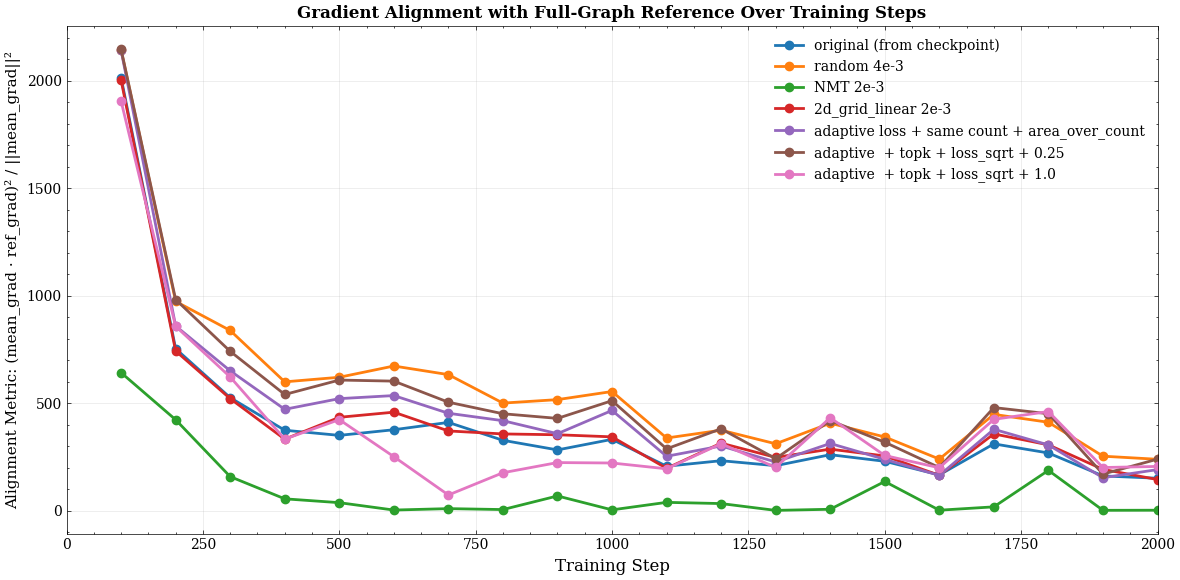


=== Gradient Alignment Metric Summary ===

                                     sampler       mean        std       min         max
                  original (from checkpoint) 236.150177 318.098419 41.028671 2013.963135
                                 random 4e-3 347.131226 360.221680 75.511444 2143.369629
                                    NMT 2e-3  45.622890 120.518974  0.072021  641.578003
                         2d_grid_linear 2e-3 263.394379 310.945435 69.545494 2002.846313
adaptive loss + same count + area_over_count 282.014801 346.463623 54.075436 2141.527832
         adaptive  + topk + loss_sqrt + 0.25 321.307007 358.073761 70.051834 2145.746094
          adaptive  + topk + loss_sqrt + 1.0 251.199890 307.871338 56.974274 1904.951294


In [17]:


show_list = [
    'ref_grad',
    'original (from checkpoint)', 
    'NMT 2e-3',
    'adaptive loss + same count + area_over_count', 
    'adaptive  + topk + loss_sqrt + 0.25',
    #'adaptive  + topk + loss_sqrt + 0.5',
    'adaptive  + topk + loss_sqrt + 1.0'
]
show_list = results.keys()  # show all

PALETTE = sns.color_palette("tab10", n_colors=len(results.keys()))
SAMPLER_COLORS = {name: PALETTE[i] for i, name in enumerate(results.keys())}
def gradient_alignment_metric(sampler_name: str, step: int) -> float:
    """
    Compute gradient alignment: (mean_grad · ref_grad)² / ||mean_grad||²
    
    Higher values indicate better alignment with the full-graph reference gradient.
    """
    mean_g = _mean_grad(sampler_name, step)
    ref_g = _ref_grad(step)
    
    if mean_g.numel() == 0 or ref_g.numel() == 0:
        return float("nan")
    
    dot_product = float(torch.dot(mean_g, ref_g))
    norm_sq = float(torch.sum(mean_g ** 2))
    norm_sq = _square_grad(sampler_name, step)
    
    if norm_sq <= 1e-20:
        return float("nan")
    
    return (dot_product ** 2) / norm_sq


# Compute alignment metric for all (sampler, step) pairs
alignment_data: dict[str, tuple[list[int], list[float]]] = {}

for sampler_name in results.keys():
    steps_list = []
    metrics_list = []
    
    for step in sorted(results[sampler_name].keys()):
        metric = gradient_alignment_metric(sampler_name, step)
        steps_list.append(step)
        metrics_list.append(metric)
    
    alignment_data[sampler_name] = (steps_list, metrics_list)

# Plot alignment metric over training steps
fig, ax = plt.subplots(figsize=(12, 6))

standard = alignment_data['original (from checkpoint)'][1]

steps_list = []
metrics_list = []
for step in sorted(results[sampler_name].keys()):
    metric = torch.sum(_ref_grad(step)**2)
    steps_list.append(step)
    metrics_list.append(metric)
alignment_data['ref_grad'] = (steps_list, metrics_list)
SAMPLER_COLORS['ref_grad'] = 'k'
upper = metrics_list

for sampler_name in show_list:

    steps, metrics = alignment_data[sampler_name]
    # normalize with standard
    metrics = [m for m, s, u in zip(metrics, standard, upper)]
    ax.plot(
        steps[1:], metrics[1:],
        marker="o", markersize=6,
        label=sampler_name,
        color=SAMPLER_COLORS[sampler_name],
        linewidth=2,
    )



ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Alignment Metric: (mean_grad · ref_grad)² / ||mean_grad||²", fontsize=11)
ax.set_title("Gradient Alignment with Full-Graph Reference Over Training Steps", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
# ax.set_ylim(-1.5, 1.2)
ax.set_xlim(0, 2000)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR.parent / "sampler_gradient_alignment_metric.png", dpi=150)
plt.show()

# Print summary stats
print("\n=== Gradient Alignment Metric Summary ===\n")
alignment_summary = []
for sampler_name in SAMPLER_CONFIGS:
    steps, metrics = alignment_data[sampler_name]
    metrics_arr = np.array(metrics)
    valid_metrics = metrics_arr[~np.isnan(metrics_arr)]
    
    if len(valid_metrics) > 0:
        alignment_summary.append({
            "sampler": sampler_name,
            "mean": float(valid_metrics.mean()),
            "std": float(valid_metrics.std()),
            "min": float(valid_metrics.min()),
            "max": float(valid_metrics.max()),
        })

alignment_df = pd.DataFrame(alignment_summary)
pd.set_option("display.float_format", "{:.6f}".format)
print(alignment_df.to_string(index=False))

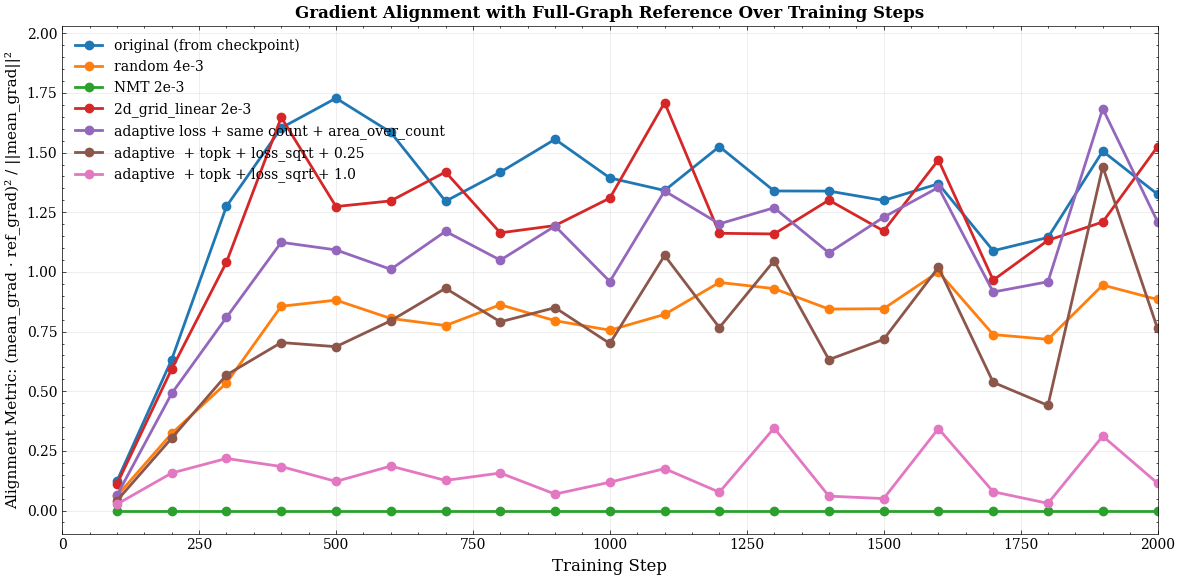


=== Gradient Alignment Metric Summary ===

                                     sampler     mean      std       min      max
                  original (from checkpoint) 1.442899 0.383928  0.097011 1.932663
                                 random 4e-3 0.900042 0.264694  0.050336 1.300721
                                    NMT 2e-3 0.000000 0.000000 -0.000000 0.000000
                         2d_grid_linear 2e-3 1.188943 0.321063  0.078575 1.709750
adaptive loss + same count + area_over_count 1.209834 0.357573  0.028342 1.684523
         adaptive  + topk + loss_sqrt + 0.25 0.922980 0.337885  0.024275 1.441119
          adaptive  + topk + loss_sqrt + 1.0 0.290543 0.196449  0.012161 0.761513


In [22]:
SAVE_FIGURE = False
show_list = [
    'ref_grad',
    'original (from checkpoint)', 
    'NMT 2e-3',
    'adaptive loss + same count + area_over_count', 
    'adaptive  + topk + loss_sqrt + 0.25',
    #'adaptive  + topk + loss_sqrt + 0.5',
    # 'adaptive  + topk + loss_sqrt + 1.0'
]
show_list = results.keys()  # show all

PALETTE = sns.color_palette("tab10", n_colors=len(results.keys()))
SAMPLER_COLORS = {name: PALETTE[i] for i, name in enumerate(results.keys())}
def gradient_normalize_variance_metric(sampler_name: str, step: int) -> float:

    'normalized gradient variance'

    return (_square_grad(sampler_name, step) - (_mean_grad(sampler_name, step)**2).sum())/(_mean_grad(sampler_name, step)**2).sum()
    # """
    # Compute gradient alignment: (mean_grad · ref_grad)² / ||mean_grad||²
    
    # Higher values indicate better alignment with the full-graph reference gradient.
    # """
    # mean_g = _mean_grad(sampler_name, step)
    # ref_g = _ref_grad(step)
    
    # if mean_g.numel() == 0 or ref_g.numel() == 0:
    #     return float("nan")
    
    # dot_product = float(torch.dot(mean_g, ref_g))
    # norm_sq = float(torch.sum(mean_g ** 2))
    # norm_sq = _square_grad(sampler_name, step)
    
    # if norm_sq <= 1e-20:
    #     return float("nan")
    
    # return norm_sq - mean_g**2


# Compute alignment metric for all (sampler, step) pairs
alignment_data2: dict[str, tuple[list[int], list[float]]] = {}

for sampler_name in results.keys():
    steps_list = []
    metrics_list = []
    
    for step in sorted(results[sampler_name].keys()):
        metric = gradient_normalize_variance_metric(sampler_name, step)
        steps_list.append(step)
        metrics_list.append(metric)
    
    alignment_data2[sampler_name] = (steps_list, metrics_list)

# Plot alignment metric over training steps
fig, ax = plt.subplots(figsize=(12, 6))

standard = alignment_data2['original (from checkpoint)'][1]

steps_list = []
metrics_list = []
for step in sorted(results[sampler_name].keys()):
    metric = torch.sum(_ref_grad(step)**2)
    steps_list.append(step)
    metrics_list.append(metric)
alignment_data2['ref_grad'] = (steps_list, metrics_list)
SAMPLER_COLORS['ref_grad'] = 'k'
upper = metrics_list

for sampler_name in show_list:

    steps, metrics = alignment_data2[sampler_name]
    # normalize with standard
    metrics = [m for m, s, u in zip(metrics, standard, upper)]
    ax.plot(
        steps[1:], metrics[1:],
        marker="o", markersize=6,
        label=sampler_name,
        color=SAMPLER_COLORS[sampler_name],
        linewidth=2,
    )



ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Alignment Metric: (mean_grad · ref_grad)² / ||mean_grad||²", fontsize=11)
ax.set_title("Gradient Alignment with Full-Graph Reference Over Training Steps", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
# ax.set_ylim(-1.5, 1.2)
ax.set_xlim(0, 2000)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR.parent / "sampler_gradient_alignment_metric.png", dpi=150)
plt.show()

# Print summary stats
print("\n=== Gradient Alignment Metric Summary ===\n")
alignment_summary = []
for sampler_name in SAMPLER_CONFIGS:
    steps, metrics = alignment_data2[sampler_name]
    metrics_arr = np.array(metrics)
    valid_metrics = metrics_arr[~np.isnan(metrics_arr)]
    
    if len(valid_metrics) > 0:
        alignment_summary.append({
            "sampler": sampler_name,
            "mean": float(valid_metrics.mean()),
            "std": float(valid_metrics.std()),
            "min": float(valid_metrics.min()),
            "max": float(valid_metrics.max()),
        })

alignment_df = pd.DataFrame(alignment_summary)
pd.set_option("display.float_format", "{:.6f}".format)
print(alignment_df.to_string(index=False))

In [ ]:
alignment_data['adaptive  + topk + loss_sqrt + 0.25']

In [15]:
import pickle
with open('paper_single_optimization.pkl', "wb") as f:
    pickle.dump(results, f)


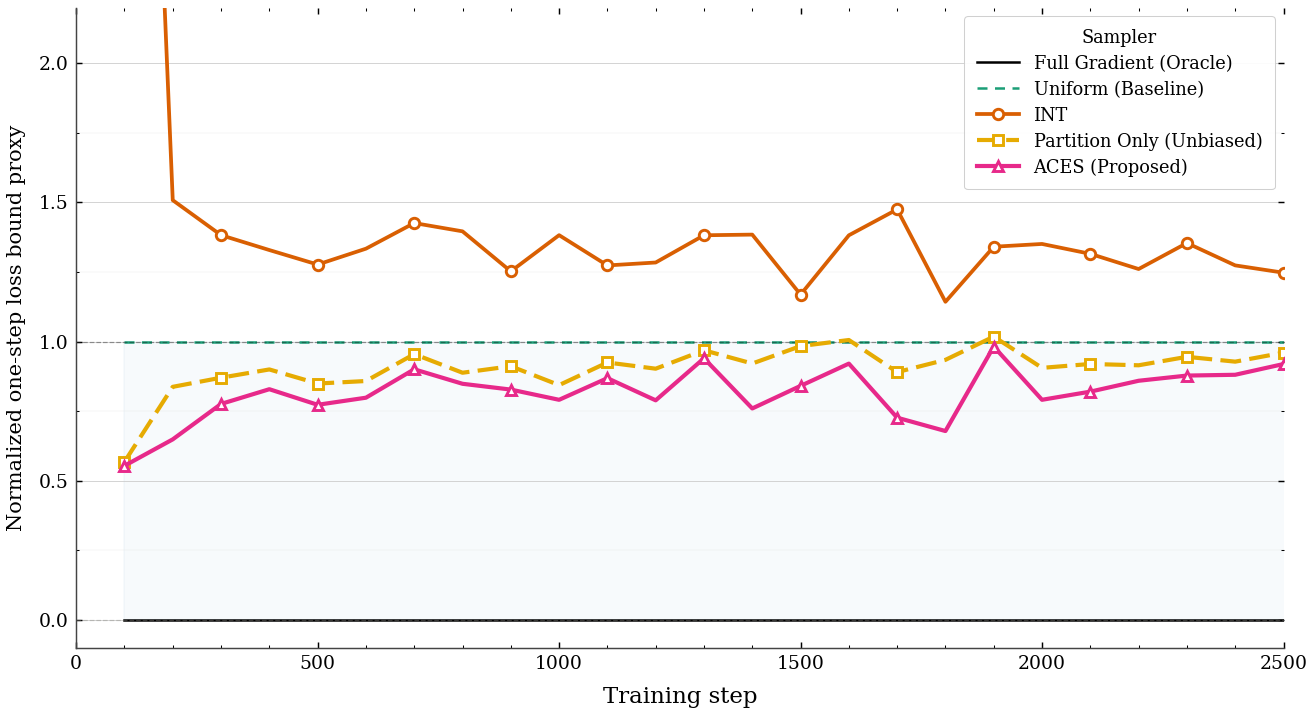

In [18]:
SAVE_FIGURE = False
import pickle

with open('paper_single_optimization.pkl', "rb") as f:
    results = pickle.load(f)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

Paper_path = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure"

# ── Color scheme ──────────────────────────────────────────────────────────────
# References: black/gray (neutral), NMT: distinct blue
# Adaptive variants share an orange-red hue family, separated by lightness+dash

COLORS = {
    'ref_grad':                                    'black',   # near-black
    'original (from checkpoint)':                  "#1B9E77",   # mid-gray
    'NMT 2e-3':                                    '#D95F02',   # blue  (distinct)
    'adaptive loss + same count + area_over_count': "#E6AB02",  # deep orange  ─┐ adaptive
    'adaptive  + topk + loss_sqrt + 0.25':          "#E7298A",  # mid orange   ─┤ family
    'adaptive  + topk + loss_sqrt + 1.0':           '#fdbe85',  # light orange ─┘
}

LINESTYLES = {
    'ref_grad':                                    'solid',   # dashed
    'original (from checkpoint)':                  (0, (4, 3)),   # dashed
    'NMT 2e-3':                                    'solid',
    'adaptive loss + same count + area_over_count': (0, (5, 2)),
    'adaptive  + topk + loss_sqrt + 0.25':          'solid',  # loosely dashed
    'adaptive  + topk + loss_sqrt + 1.0':           (0, (2, 2)),  # densely dashed
}

MARKERS = {
    'ref_grad':                                    None,
    'original (from checkpoint)':                  None,
    'NMT 2e-3':                                    'o',
    'adaptive loss + same count + area_over_count': 's',
    'adaptive  + topk + loss_sqrt + 0.25':          '^',
    # 'adaptive  + topk + loss_sqrt + 1.0':           'D',
}

LABELS = {
    'ref_grad':                                    'Full Gradient (Oracle)',
    'original (from checkpoint)':                  'Uniform (Baseline)',
    'NMT 2e-3':                                    'INT',
    'adaptive loss + same count + area_over_count': r'Partition Only (Unbiased)',
    'adaptive  + topk + loss_sqrt + 0.25':          r'ACES (Proposed)',
    'adaptive  + topk + loss_sqrt + 1.0':           r'Adaptive  Weighted by Residual, $\alpha$=2.0',
}

LINEWIDTHS = {
    'ref_grad':                   1.2,
    'original (from checkpoint)': 1.2,
    'NMT 2e-3':                   1.8,
    'adaptive loss + same count + area_over_count': 2.0,
    'adaptive  + topk + loss_sqrt + 0.25':          2.0,
    'adaptive  + topk + loss_sqrt + 1.0':           2.0,
}

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

# thin spines, no top/right
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_linewidth(0.7)
    ax.spines[spine].set_color('#444')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ── Compute reference norm & normalise ────────────────────────────────────────
steps_list, ref_norm_list = [], []
for step in sorted(results[next(iter(results))].keys()):
    ref_norm_list.append(float(torch.sum(_ref_grad(step) ** 2)))
    steps_list.append(step)
alignment_data['ref_grad'] = (steps_list, ref_norm_list)

standard = alignment_data['original (from checkpoint)'][1]
upper    = ref_norm_list

# ── Plot ──────────────────────────────────────────────────────────────────────
for name in MARKERS.keys():
    steps, metrics = alignment_data[name]
    normed = [
        (m - u) / (s - u) if abs(u - s) > 1e-20 else float('nan')
        for m, s, u in zip(metrics, standard, upper)
    ]
    mk = MARKERS[name]
    ax.plot(
        steps[1:], normed[1:],
        color=COLORS[name],
        linestyle=LINESTYLES[name],
        linewidth=LINEWIDTHS[name],
        marker=mk,
        markersize=5 if mk else 0,
        markerfacecolor='white' if mk else None,
        markeredgewidth=1.4,
        markevery=2,          # avoid clutter on dense x-axis
        label=LABELS[name],
        zorder=3 if 'adaptive' in name.lower() else 2,
    )

# ── Reference band ────────────────────────────────────────────────────────────
# Shade the 0–1 "useful" band lightly so readers see the normalisation anchors
ax.axhline(1.0, color='#1a1a1a', lw=0.6, ls='--', alpha=0.4)
ax.axhline(0.0, color='#888780', lw=0.6, ls='--', alpha=0.4)
ax.fill_between(steps[1:], 0, 1, alpha=0.04, color='steelblue', zorder=0)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Training step', fontsize=11, labelpad=6)
ax.set_ylabel(
    r'Normalized one-step loss bound proxy',
    fontsize=10, labelpad=6,
)
ax.set_ylim(-0.1, 2.2)
ax.set_xlim(0, 2500)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.tick_params(axis='both', labelsize=9, length=3, width=0.7)

ax.grid(axis='y', which='major', lw=0.4, color='#ccc', zorder=0)
ax.grid(axis='y', which='minor', lw=0.2, color='#e8e8e8', zorder=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=8.5,
    frameon=True,
    framealpha=0.92,
    edgecolor='#ccc',
    facecolor='white',
    loc='upper right',
    handlelength=2.4,
    handleheight=0.9,
    borderpad=0.7,
    labelspacing=0.45,
    title='Sampler',
    title_fontsize=8.5,
)
leg.get_frame().set_linewidth(0.5)

plt.tight_layout(pad=1.2)
if SAVE_FIGURE:
    plt.savefig(
        f"{Paper_path}/sampler_gradient_alignment_metric.pdf",
        dpi=300, bbox_inches='tight',
    )
    plt.savefig(
        f"{Paper_path}/sampler_gradient_alignment_metric.png",
        dpi=300, bbox_inches='tight',
    )
plt.show()

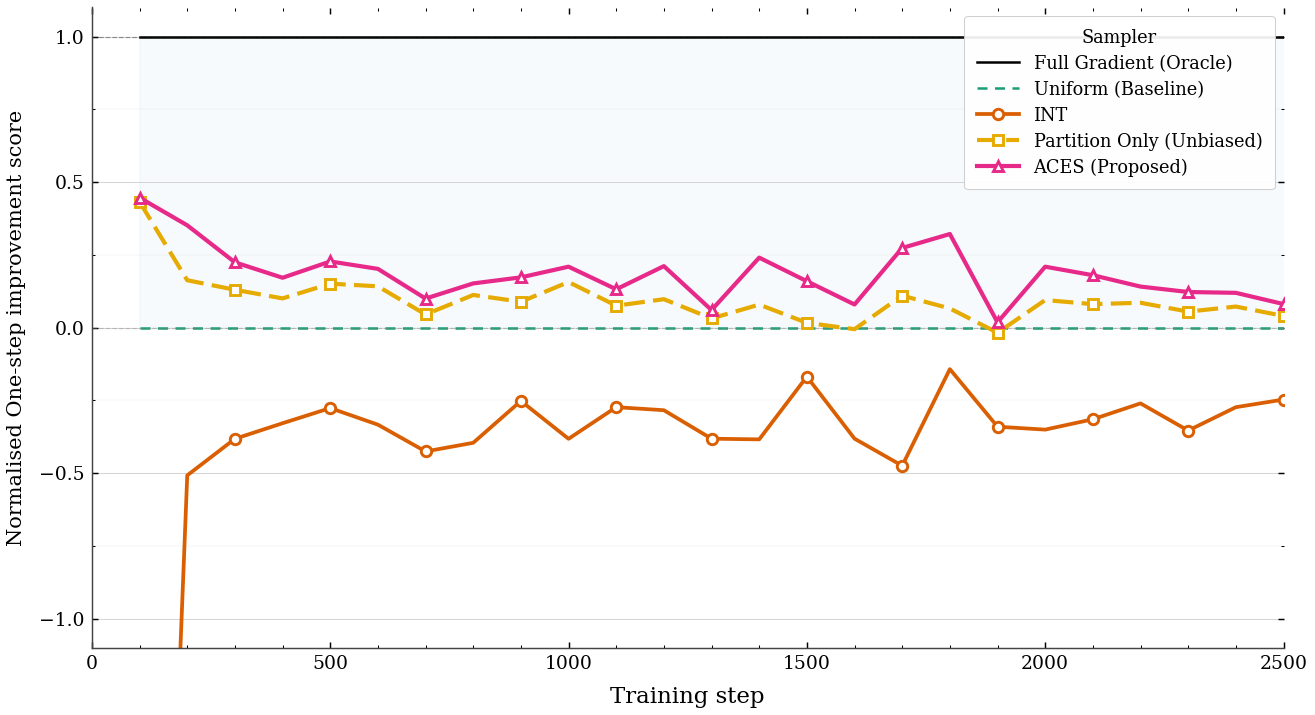

In [34]:
SAVE_FIGURE = True
import pickle

with open('paper_single_optimization.pkl', "rb") as f:
    results = pickle.load(f)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

Paper_path = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure"

# ── Color scheme ──────────────────────────────────────────────────────────────
# References: black/gray (neutral), NMT: distinct blue
# Adaptive variants share an orange-red hue family, separated by lightness+dash

COLORS = {
    'ref_grad':                                    'black',   # near-black
    'original (from checkpoint)':                  "#1B9E77",   # mid-gray
    'NMT 2e-3':                                    '#D95F02',   # blue  (distinct)
    'adaptive loss + same count + area_over_count': "#E6AB02",  # deep orange  ─┐ adaptive
    'adaptive  + topk + loss_sqrt + 0.25':          "#E7298A",  # mid orange   ─┤ family
    'adaptive  + topk + loss_sqrt + 1.0':           '#fdbe85',  # light orange ─┘
}

LINESTYLES = {
    'ref_grad':                                    'solid',   # dashed
    'original (from checkpoint)':                  (0, (4, 3)),   # dashed
    'NMT 2e-3':                                    'solid',
    'adaptive loss + same count + area_over_count': (0, (5, 2)),
    'adaptive  + topk + loss_sqrt + 0.25':          'solid',  # loosely dashed
    'adaptive  + topk + loss_sqrt + 1.0':           (0, (2, 2)),  # densely dashed
}

MARKERS = {
    'ref_grad':                                    None,
    'original (from checkpoint)':                  None,
    'NMT 2e-3':                                    'o',
    'adaptive loss + same count + area_over_count': 's',
    'adaptive  + topk + loss_sqrt + 0.25':          '^',
    # 'adaptive  + topk + loss_sqrt + 1.0':           'D',
}

LABELS = {
    'ref_grad':                                    'Full Gradient (Oracle)',
    'original (from checkpoint)':                  'Uniform (Baseline)',
    'NMT 2e-3':                                    'INT',
    'adaptive loss + same count + area_over_count': r'Partition Only (Unbiased)',
    'adaptive  + topk + loss_sqrt + 0.25':          r'ACES (Proposed)',
    'adaptive  + topk + loss_sqrt + 1.0':           r'Adaptive  Weighted by Residual, $\alpha$=2.0',
}

LINEWIDTHS = {
    'ref_grad':                   1.2,
    'original (from checkpoint)': 1.2,
    'NMT 2e-3':                   1.8,
    'adaptive loss + same count + area_over_count': 2.0,
    'adaptive  + topk + loss_sqrt + 0.25':          2.0,
    'adaptive  + topk + loss_sqrt + 1.0':           2.0,
}

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

# thin spines, no top/right
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_linewidth(0.7)
    ax.spines[spine].set_color('#444')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ── Compute reference norm & normalise ────────────────────────────────────────
steps_list, ref_norm_list = [], []
for step in sorted(results[next(iter(results))].keys()):
    ref_norm_list.append(float(torch.sum(_ref_grad(step) ** 2)))
    steps_list.append(step)
alignment_data['ref_grad'] = (steps_list, ref_norm_list)

standard = alignment_data['original (from checkpoint)'][1]
upper    = ref_norm_list

# ── Plot ──────────────────────────────────────────────────────────────────────
for name in MARKERS.keys():
    steps, metrics = alignment_data[name]
    normed = [
        (m - s) / (u-s) if abs(u - s) > 1e-20 else float('nan')
        for m, s, u in zip(metrics, standard, upper)
    ]
    mk = MARKERS[name]
    ax.plot(
        steps[1:], normed[1:],
        color=COLORS[name],
        linestyle=LINESTYLES[name],
        linewidth=LINEWIDTHS[name],
        marker=mk,
        markersize=5 if mk else 0,
        markerfacecolor='white' if mk else None,
        markeredgewidth=1.4,
        markevery=2,          # avoid clutter on dense x-axis
        label=LABELS[name],
        zorder=3 if 'adaptive' in name.lower() else 2,
    )

# ── Reference band ────────────────────────────────────────────────────────────
# Shade the 0–1 "useful" band lightly so readers see the normalisation anchors
ax.axhline(1.0, color='#1a1a1a', lw=0.6, ls='--', alpha=0.4)
ax.axhline(0.0, color='#888780', lw=0.6, ls='--', alpha=0.4)
ax.fill_between(steps[1:], 0, 1, alpha=0.04, color='steelblue', zorder=0)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Training step', fontsize=11, labelpad=6)
ax.set_ylabel(
    r'Normalised One-step improvement score',
    fontsize=10, labelpad=6,
)
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(0, 2500)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.tick_params(axis='both', labelsize=9, length=3, width=0.7)

ax.grid(axis='y', which='major', lw=0.4, color='#ccc', zorder=0)
ax.grid(axis='y', which='minor', lw=0.2, color='#e8e8e8', zorder=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=8.5,
    frameon=True,
    framealpha=0.92,
    edgecolor='#ccc',
    facecolor='white',
    loc='upper right',
    handlelength=2.4,
    handleheight=0.9,
    borderpad=0.7,
    labelspacing=0.45,
    title='Sampler',
    title_fontsize=8.5,
)
leg.get_frame().set_linewidth(0.5)

plt.tight_layout(pad=1.2)
if SAVE_FIGURE:
    plt.savefig(
        f"{Paper_path}/sampler_gradient_alignment_metric_positive.pdf",
        dpi=300, bbox_inches='tight',
    )
    plt.savefig(
        f"{Paper_path}/sampler_gradient_alignment_metric_positive.png",
        dpi=300, bbox_inches='tight',
    )
plt.show()

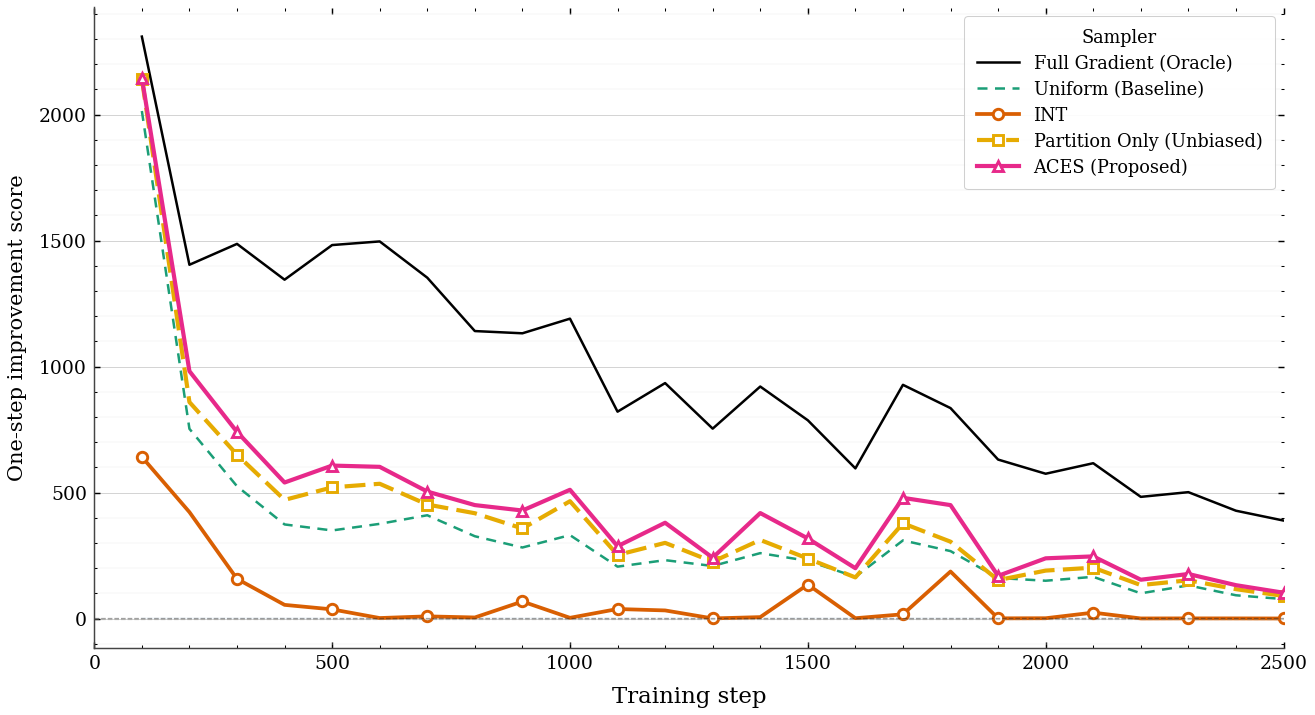

In [35]:
SAVE_FIGURE = True
import pickle

with open('paper_single_optimization.pkl', "rb") as f:
    results = pickle.load(f)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

Paper_path = "/pscratch/sd/g/gzhao27/INR/INR_SAMPLE/Results/latex/NIPS-2026-INR-Sampling/figure"

# ── Color scheme ──────────────────────────────────────────────────────────────
# References: black/gray (neutral), NMT: distinct blue
# Adaptive variants share an orange-red hue family, separated by lightness+dash

COLORS = {
    'ref_grad':                                    'black',   # near-black
    'original (from checkpoint)':                  "#1B9E77",   # mid-gray
    'NMT 2e-3':                                    '#D95F02',   # blue  (distinct)
    'adaptive loss + same count + area_over_count': "#E6AB02",  # deep orange  ─┐ adaptive
    'adaptive  + topk + loss_sqrt + 0.25':          "#E7298A",  # mid orange   ─┤ family
    'adaptive  + topk + loss_sqrt + 1.0':           '#fdbe85',  # light orange ─┘
}

LINESTYLES = {
    'ref_grad':                                    'solid',   # dashed
    'original (from checkpoint)':                  (0, (4, 3)),   # dashed
    'NMT 2e-3':                                    'solid',
    'adaptive loss + same count + area_over_count': (0, (5, 2)),
    'adaptive  + topk + loss_sqrt + 0.25':          'solid',  # loosely dashed
    'adaptive  + topk + loss_sqrt + 1.0':           (0, (2, 2)),  # densely dashed
}

MARKERS = {
    'ref_grad':                                    None,
    'original (from checkpoint)':                  None,
    'NMT 2e-3':                                    'o',
    'adaptive loss + same count + area_over_count': 's',
    'adaptive  + topk + loss_sqrt + 0.25':          '^',
    # 'adaptive  + topk + loss_sqrt + 1.0':           'D',
}

LABELS = {
    'ref_grad':                                    'Full Gradient (Oracle)',
    'original (from checkpoint)':                  'Uniform (Baseline)',
    'NMT 2e-3':                                    'INT',
    'adaptive loss + same count + area_over_count': r'Partition Only (Unbiased)',
    'adaptive  + topk + loss_sqrt + 0.25':          r'ACES (Proposed)',
    'adaptive  + topk + loss_sqrt + 1.0':           r'Adaptive  Weighted by Residual, $\alpha$=2.0',
}

LINEWIDTHS = {
    'ref_grad':                   1.2,
    'original (from checkpoint)': 1.2,
    'NMT 2e-3':                   1.8,
    'adaptive loss + same count + area_over_count': 2.0,
    'adaptive  + topk + loss_sqrt + 0.25':          2.0,
    'adaptive  + topk + loss_sqrt + 1.0':           2.0,
}

# ── Figure setup ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

# thin spines, no top/right
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
for spine in ('left', 'bottom'):
    ax.spines[spine].set_linewidth(0.7)
    ax.spines[spine].set_color('#444')

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ── Compute reference norm & normalise ────────────────────────────────────────
steps_list, ref_norm_list = [], []
for step in sorted(results[next(iter(results))].keys()):
    ref_norm_list.append(float(torch.sum(_ref_grad(step) ** 2)))
    steps_list.append(step)
alignment_data['ref_grad'] = (steps_list, ref_norm_list)

standard = alignment_data['original (from checkpoint)'][1]
upper    = ref_norm_list

# ── Plot ──────────────────────────────────────────────────────────────────────
for name in MARKERS.keys():
    steps, metrics = alignment_data[name]
    normed = [
        m if abs(u - s) > 1e-20 else float('nan')
        for m, s, u in zip(metrics, standard, upper)
    ]
    mk = MARKERS[name]
    ax.plot(
        steps[1:], normed[1:],
        color=COLORS[name],
        linestyle=LINESTYLES[name],
        linewidth=LINEWIDTHS[name],
        marker=mk,
        markersize=5 if mk else 0,
        markerfacecolor='white' if mk else None,
        markeredgewidth=1.4,
        markevery=2,          # avoid clutter on dense x-axis
        label=LABELS[name],
        zorder=3 if 'adaptive' in name.lower() else 2,
    )

# ── Reference band ────────────────────────────────────────────────────────────
# Shade the 0–1 "useful" band lightly so readers see the normalisation anchors
ax.axhline(1.0, color='#1a1a1a', lw=0.6, ls='--', alpha=0.4)
ax.axhline(0.0, color='#888780', lw=0.6, ls='--', alpha=0.4)
ax.fill_between(steps[1:], 0, 1, alpha=0.04, color='steelblue', zorder=0)

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlabel('Training step', fontsize=11, labelpad=6)
ax.set_ylabel(
    r'One-step improvement score',
    fontsize=10, labelpad=6,
)
# ax.set_ylim(-1.1, 1.1)
ax.set_xlim(0, 2500)
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
ax.tick_params(axis='both', labelsize=9, length=3, width=0.7)

ax.grid(axis='y', which='major', lw=0.4, color='#ccc', zorder=0)
ax.grid(axis='y', which='minor', lw=0.2, color='#e8e8e8', zorder=0)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
leg = ax.legend(
    fontsize=8.5,
    frameon=True,
    framealpha=0.92,
    edgecolor='#ccc',
    facecolor='white',
    loc='upper right',
    handlelength=2.4,
    handleheight=0.9,
    borderpad=0.7,
    labelspacing=0.45,
    title='Sampler',
    title_fontsize=8.5,
)
leg.get_frame().set_linewidth(0.5)

plt.tight_layout(pad=1.2)
if SAVE_FIGURE:
    plt.savefig(
        f"{Paper_path}/sampler_gradient_alignment_metric_original.pdf",
        dpi=300, bbox_inches='tight',
    )
    plt.savefig(
        f"{Paper_path}/sampler_gradient_alignment_metric_original.png",
        dpi=300, bbox_inches='tight',
    )
plt.show()

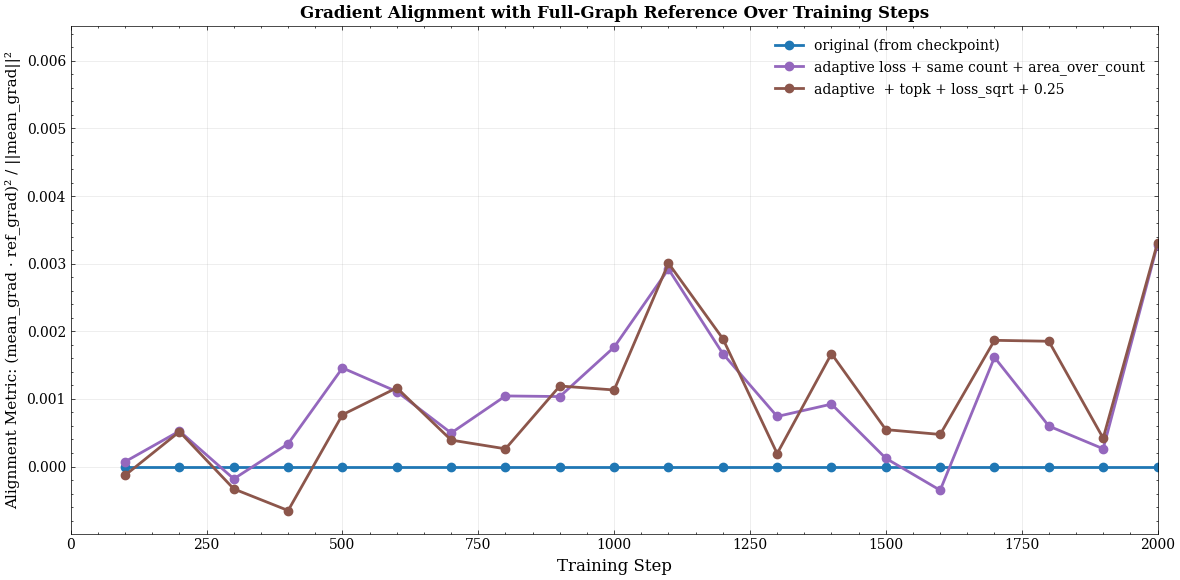


=== Gradient Alignment Metric Summary ===

                                     sampler      mean      std       min       max
                  original (from checkpoint) 20.689416 8.154469 10.969196 47.563736
                                 random 4e-3 22.843968 8.221129 12.334646 47.686922
                                    NMT 2e-3  3.832640 5.561813 -1.772734 25.329391
                         2d_grid_linear 2e-3 21.487096 7.613416 12.271074 47.160913
adaptive loss + same count + area_over_count 21.631980 8.135334 11.930436 47.725344
         adaptive  + topk + loss_sqrt + 0.25 21.664691 7.954796 12.067919 47.271997
          adaptive  + topk + loss_sqrt + 1.0 15.941321 6.508729  8.751332 44.220790


In [29]:
SAVE_FIGURE = False
show_list = [
    # 'ref_grad',
    'original (from checkpoint)', 
    # 'NMT 2e-3',
    'adaptive loss + same count + area_over_count', 
    'adaptive  + topk + loss_sqrt + 0.25',
    #'adaptive  + topk + loss_sqrt + 0.5',
    # 'adaptive  + topk + loss_sqrt + 1.0'
]
# show_list = results.keys()  # show all

PALETTE = sns.color_palette("tab10", n_colors=len(results.keys()))
SAMPLER_COLORS = {name: PALETTE[i] for i, name in enumerate(results.keys())}
def gradient_normalize_variance_metric(sampler_name: str, step: int) -> float:

    """
    Compute gradient alignment: (mean_grad · ref_grad)² / ||mean_grad||²
    
    Higher values indicate better alignment with the full-graph reference gradient.
    """
    mean_g = _mean_grad(sampler_name, step)
    ref_g = _ref_grad(step)
    
    if mean_g.numel() == 0 or ref_g.numel() == 0:
        return float("nan")
    
    dot_product = float(torch.dot(mean_g, ref_g))
    norm_sq = float(torch.sum(mean_g ** 2))
    norm_sq = _square_grad(sampler_name, step)
    
    if norm_sq <= 1e-20:
        return float("nan")
    
    return dot_product/float(torch.sum(mean_g ** 2).sqrt())
    # """
    # Compute gradient alignment: (mean_grad · ref_grad)² / ||mean_grad||²
    
    # Higher values indicate better alignment with the full-graph reference gradient.
    # """
    # mean_g = _mean_grad(sampler_name, step)
    # ref_g = _ref_grad(step)
    
    # if mean_g.numel() == 0 or ref_g.numel() == 0:
    #     return float("nan")
    
    # dot_product = float(torch.dot(mean_g, ref_g))
    # norm_sq = float(torch.sum(mean_g ** 2))
    # norm_sq = _square_grad(sampler_name, step)
    
    # if norm_sq <= 1e-20:
    #     return float("nan")
    
    # return norm_sq - mean_g**2


# Compute alignment metric for all (sampler, step) pairs
alignment_data2: dict[str, tuple[list[int], list[float]]] = {}

for sampler_name in results.keys():
    steps_list = []
    metrics_list = []
    
    for step in sorted(results[sampler_name].keys()):
        metric = gradient_normalize_variance_metric(sampler_name, step)
        steps_list.append(step)
        metrics_list.append(metric)
    
    alignment_data2[sampler_name] = (steps_list, metrics_list)

# Plot alignment metric over training steps
fig, ax = plt.subplots(figsize=(12, 6))

standard = alignment_data2['original (from checkpoint)'][1]

steps_list = []
metrics_list = []
for step in sorted(results[sampler_name].keys()):
    metric = torch.sum(_ref_grad(step)**2)
    steps_list.append(step)
    metrics_list.append(metric)
alignment_data2['ref_grad'] = (steps_list, metrics_list)
SAMPLER_COLORS['ref_grad'] = 'k'
upper = metrics_list

for sampler_name in show_list:

    steps, metrics = alignment_data2[sampler_name]
    # normalize with standard
    metrics = [(m-s)/(u-s) for m, s, u in zip(metrics, standard, upper)]
    ax.plot(
        steps[1:], metrics[1:],
        marker="o", markersize=6,
        label=sampler_name,
        color=SAMPLER_COLORS[sampler_name],
        linewidth=2,
    )



ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Alignment Metric: (mean_grad · ref_grad)² / ||mean_grad||²", fontsize=11)
ax.set_title("Gradient Alignment with Full-Graph Reference Over Training Steps", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
# ax.set_ylim(-1.5, 1.2)
ax.set_xlim(0, 2000)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR.parent / "sampler_gradient_alignment_metric.png", dpi=150)
plt.show()

# Print summary stats
print("\n=== Gradient Alignment Metric Summary ===\n")
alignment_summary = []
for sampler_name in SAMPLER_CONFIGS:
    steps, metrics = alignment_data2[sampler_name]
    metrics_arr = np.array(metrics)
    valid_metrics = metrics_arr[~np.isnan(metrics_arr)]
    
    if len(valid_metrics) > 0:
        alignment_summary.append({
            "sampler": sampler_name,
            "mean": float(valid_metrics.mean()),
            "std": float(valid_metrics.std()),
            "min": float(valid_metrics.min()),
            "max": float(valid_metrics.max()),
        })

alignment_df = pd.DataFrame(alignment_summary)
pd.set_option("display.float_format", "{:.6f}".format)
print(alignment_df.to_string(index=False))

In [24]:
show_list

dict_keys(['original (from checkpoint)', 'random 4e-3', 'NMT 2e-3', '2d_grid_linear 2e-3', 'adaptive loss + same count + area_over_count', 'adaptive  + topk + loss_sqrt + 0.25', 'adaptive  + topk + loss_sqrt + 1.0'])

## test specified sampler

In [ ]:

adaptive_cfg = _apply_sampler_overrides(cfg, SAMPLER_CONFIGS["adaptive  + topk + loss_sqrt"])
adaptive_sampler = create_inr_sampler(
    adaptive_cfg,
    inr,
    graph,
    current_date_str="paper_fig_",
    run_name="iter300",
    device=DEVICE,
)
nmt_sampled_graph = _call_sampler(adaptive_sampler, graph, step=300)
nmt_sampled_graph

In [ ]:
show_list = [
    'ref_grad',
    'original (from checkpoint)', 
    'NMT 2e-3',
    'adaptive loss + same count + area_over_count', 
    'adaptive  + topk + loss_sqrt + 0.25',
    #'adaptive  + topk + loss_sqrt + 0.5',
]

show_list = list(results.keys())  # show all
show_list.append('ref_grad')

PALETTE = sns.color_palette("tab10", n_colors=len(results.keys()))
SAMPLER_COLORS = {name: PALETTE[i] for i, name in enumerate(results.keys())}
SAMPLER_COLORS['ref_grad'] = 'k'
def gradient_alignment_metric(sampler_name: str, step: int) -> float:
    """
    Compute gradient alignment: (mean_grad · ref_grad)² / ||mean_grad||²
    
    Higher values indicate better alignment with the full-graph reference gradient.
    """
    mean_g = _mean_grad(sampler_name, step)
    ref_g = _ref_grad(step)
    
    if mean_g.numel() == 0 or ref_g.numel() == 0:
        return float("nan")
    
    dot_product = float(torch.dot(mean_g, ref_g))
    norm_sq = float(torch.sum(mean_g ** 2))
    norm_sq = _square_grad(sampler_name, step)
    
    if norm_sq <= 1e-20:
        return float("nan")
    
    return norm_sq


# Compute alignment metric for all (sampler, step) pairs
alignment_data: dict[str, tuple[list[int], list[float]]] = {}

for sampler_name in results.keys():
    steps_list = []
    metrics_list = []
    
    for step in sorted(results[sampler_name].keys()):
        metric = gradient_alignment_metric(sampler_name, step)
        steps_list.append(step)
        metrics_list.append(metric)
    
    alignment_data[sampler_name] = (steps_list, metrics_list)

# Plot alignment metric over training steps
fig, ax = plt.subplots(figsize=(12, 6))

standard = alignment_data['original (from checkpoint)'][1]

steps_list = []
metrics_list = []
for step in sorted(results[sampler_name].keys()):
    metric = torch.sum(_ref_grad(step)**2)
    steps_list.append(step)
    metrics_list.append(metric)
alignment_data['ref_grad'] = (steps_list, metrics_list)
SAMPLER_COLORS['ref_grad'] = 'k'
upper = metrics_list

for sampler_name in show_list:

    steps, metrics = alignment_data[sampler_name]
    # normalize with standard
    metrics = [m for m, s, u in zip(metrics, standard, upper)]
    ax.plot(
        steps[1:], metrics[1:],
        marker="o", markersize=6,
        label=sampler_name,
        color=SAMPLER_COLORS[sampler_name],
        linewidth=2,
    )



ax.set_xlabel("Training Step", fontsize=12)
ax.set_ylabel("Alignment Metric: (mean_grad · ref_grad)² / ||mean_grad||²", fontsize=11)
ax.set_title("Gradient Alignment with Full-Graph Reference Over Training Steps", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR.parent / "sampler_gradient_alignment_metric.png", dpi=150)
plt.show()

# Print summary stats
print("\n=== Gradient Alignment Metric Summary ===\n")
alignment_summary = []
for sampler_name in SAMPLER_CONFIGS:
    steps, metrics = alignment_data[sampler_name]
    metrics_arr = np.array(metrics)
    valid_metrics = metrics_arr[~np.isnan(metrics_arr)]
    
    if len(valid_metrics) > 0:
        alignment_summary.append({
            "sampler": sampler_name,
            "mean": float(valid_metrics.mean()),
            "std": float(valid_metrics.std()),
            "min": float(valid_metrics.min()),
            "max": float(valid_metrics.max()),
        })

alignment_df = pd.DataFrame(alignment_summary)
pd.set_option("display.float_format", "{:.6f}".format)
print(alignment_df.to_string(index=False))

In [ ]:
nmt_sampled_graph.weight.max()